In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve, average_precision_score
from lightgbm import LGBMClassifier
import joblib
import os
import shap

In [3]:
# Load processed data
df = pd.read_csv('../data/processed/telco_features.csv')

# Recreate feature matrix and target
X = df[[c for c in df.columns if c != 'Churn']]
y = df['Churn']

# Recreate identical trian/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Load saved model
model = joblib.load('../models/tuned_lgbm.joblib')

# Verification
print("Data loaded successfully")
print(f"Dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"\nModel type: {type(model).__name__}")


Data loaded successfully
Dataset shape: (7032, 30)
X_train shape: (5625, 29)
X_test shape: (1407, 29)

Model type: LGBMClassifier


In [4]:

y_pred_proba = model.predict_proba(X_test)[:, 1]

# Default threshold = 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

# Classification Report
print('\nClassification Report (Threshold = 0.5)')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ROC-AUC Score: 0.8404

Classification Report (Threshold = 0.5)
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
[[919 114]
 [180 194]]


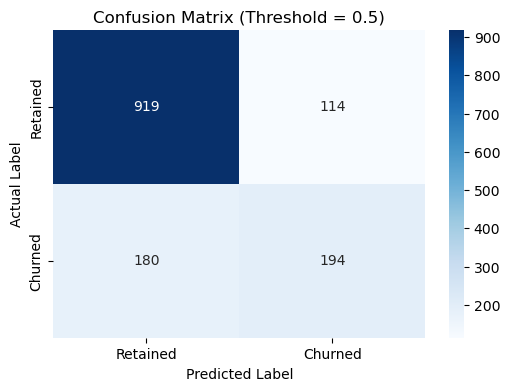

In [ ]:
# Plot 
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.savefig('../images/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

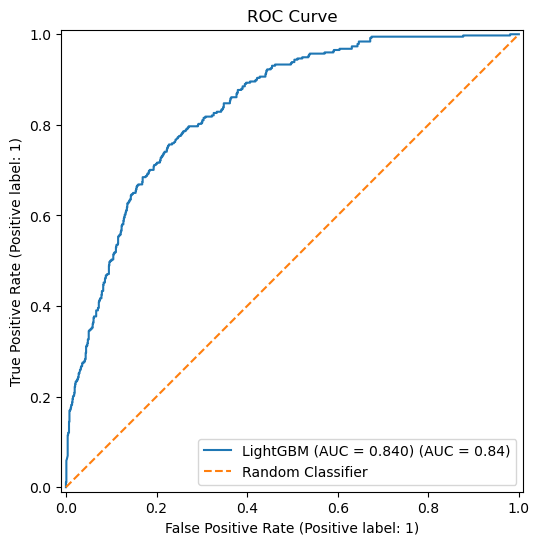

In [15]:
# Create ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name=f'LightGBM (AUC = {roc_auc:.3f})',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.savefig('../images/08_roc_curve.png', dpi=300, bbox_inches='tight')

plt.show()

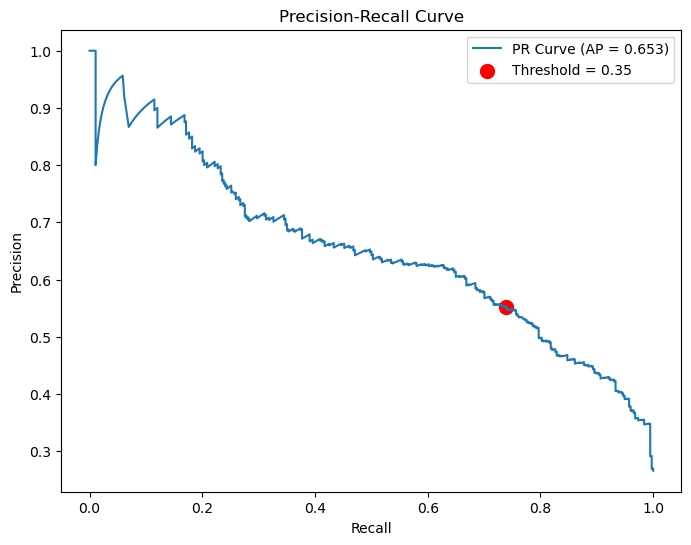

In [19]:
# Get precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute average precision (area under PR curve)
ap_score = average_precision_score(y_test, y_pred_proba)

# Find point closest to threshold = 0.35
idx = np.argmin(np.abs(thresholds - 0.35))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})')

# Mark 0.35 threshold point
plt.scatter(
    recall[idx],
    precision[idx],
    color='red',
    s=100,
    label='Threshold = 0.35'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig('../images/08_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Two thresholds
y_pred_05 = (y_pred_proba >= 0.5).astype(int)
y_pred_035 = (y_pred_proba >= 0.35).astype(int)

# Get classification reports
report_05 = classification_report(y_test, y_pred_05, output_dict=True)
report_035 = classification_report(y_test, y_pred_035, output_dict=True)

# Extract churn class (1) metrics only
comparison = pd.DataFrame({
    'Threshold = 0.5': {
        'Precision': report_05['1']['precision'],
        'Recall': report_05['1']['recall'],
        'F1-score': report_05['1']['f1-score']
    },
    'Threshold = 0.35': {
        'Precision': report_035['1']['precision'],
        'Recall': report_035['1']['recall'],
        'F1-score': report_035['1']['f1-score']
    }
})

print('\nChurn Class (1) Metrics Comparison\n')
print(comparison)



Churn Class (1) Metrics Comparison

           Threshold = 0.5  Threshold = 0.35
Precision         0.629870          0.553106
Recall            0.518717          0.737968
F1-score          0.568915          0.632302


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


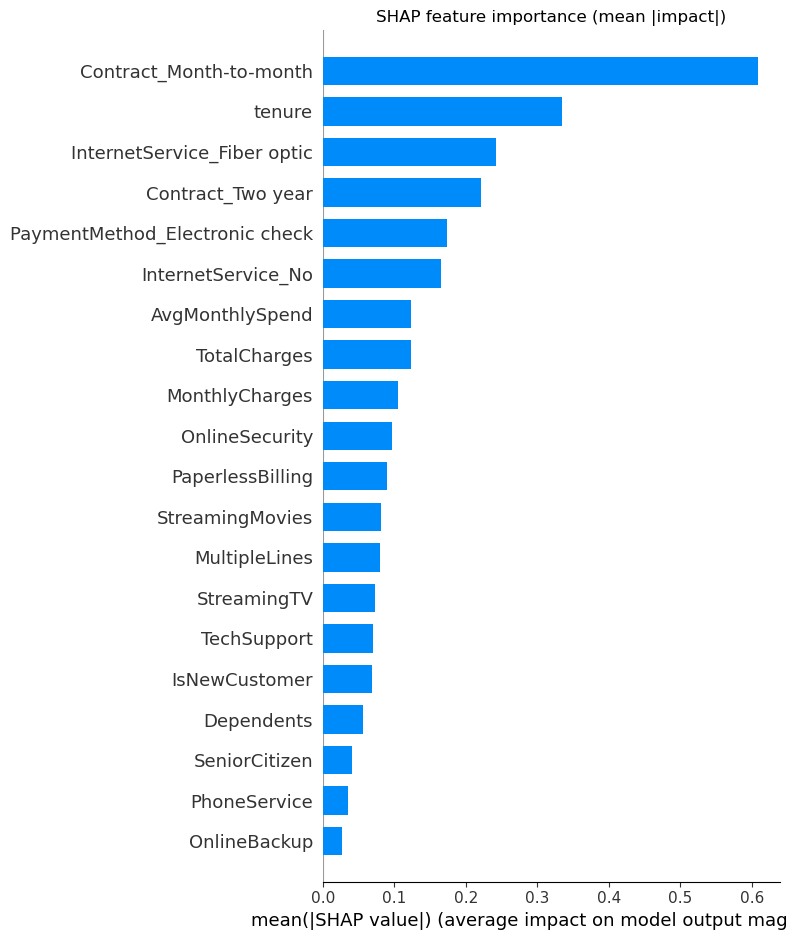

In [30]:

explainer = shap.TreeExplainer(model)

shap_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type='bar',
    show=False
)

plt.title('SHAP feature importance (mean |impact|)')
plt.tight_layout()
plt.savefig('../images/08_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

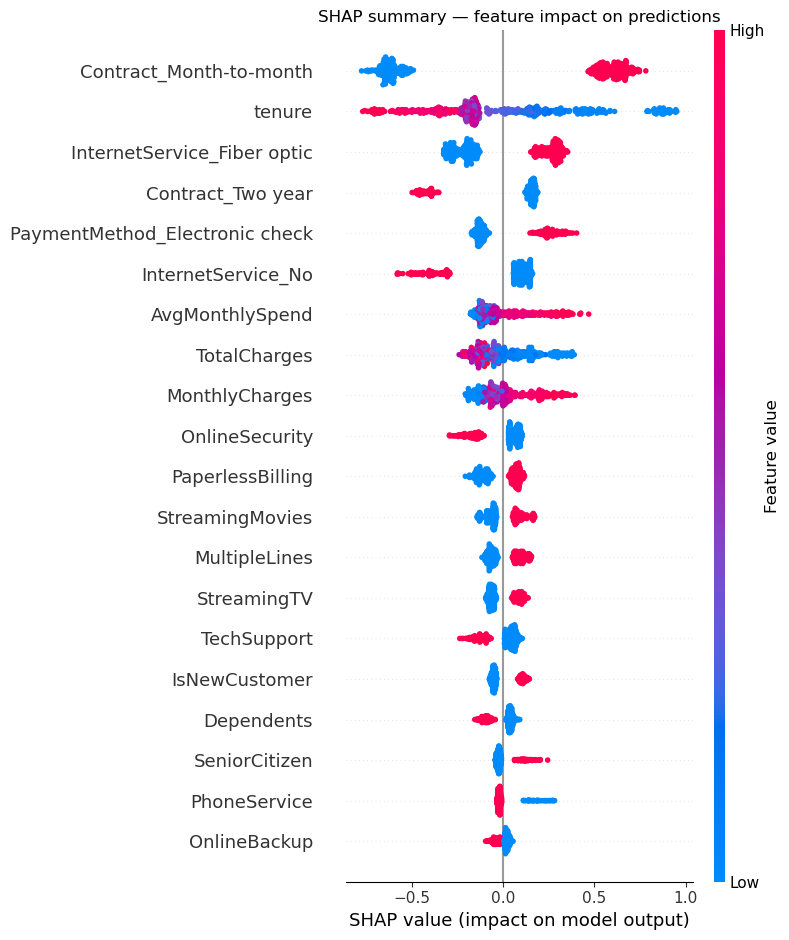

In [29]:
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    show=False
)
plt.title("SHAP summary — feature impact on predictions")
plt.tight_layout()
plt.savefig("../images/08_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Business Interpretation

The model identifies four high-risk customer profiles that account for the majority
of predicted churn. These are actionable segments, not statistical abstractions.

**1. Month-to-month customers in their first year**
The two highest-impact signals in the SHAP analysis are contract type and tenure.
A new customer on a month-to-month contract faces no switching cost and has not yet
built inertia with the service. This is the single highest-risk combination in the
dataset — churn rate in the 0–12 month window was 47.4% in EDA.
*Intervention: early incentive to upgrade to a one-year contract within the first
3 months. The gap between month-to-month (42.7%) and one-year (11.3%) churn rates
suggests even a modest contract upgrade dramatically reduces risk.*

**2. Fiber optic customers paying high monthly charges**
Fiber optic customers churn at 41.9% — more than double the DSL rate of 19.0%.
Combined with high MonthlyCharges, this profile likely reflects customers who feel
the value doesn't match the price.
*Intervention: proactive service quality check or loyalty discount for fiber
customers exceeding a monthly charge threshold.*

**3. Electronic check payment customers**
Electronic check carries the highest churn rate of any payment method (45.3%).
This is likely a proxy for low engagement — customers who haven't set up automatic
payments are less financially committed to the service.
*Intervention: targeted campaign to migrate electronic check customers to automatic
payment, which correlates with significantly lower churn (15–17%).*

**4. Senior citizens without support services**
Senior citizens churn at 41.7% vs 23.6% for non-seniors. Customers without
OnlineSecurity or TechSupport churn at roughly twice the rate of those who have them.
The combination of senior + no support bundle is a concentrated risk segment.
*Intervention: bundled support service offer targeting senior customers, framed
around ease of use rather than upselling.*

**On the recommended threshold (0.35):**
At the default 0.5 threshold, the model misses 180 out of 374 churners — nearly half.
At 0.35, it catches 276 out of 374 (73.8% recall), flagging 81 additional at-risk
customers for retention action. Each false alarm costs one unnecessary retention offer.
Each missed churner costs the full lifetime value of that customer.
The 0.35 threshold is the right operating point for a retention use case.

## Evaluation Summary

**Model:** LightGBM (Optuna tuned, 5-fold CV, 100 trials)  
**Test set:** 1,407 customers (20% stratified hold-out, never seen during training or tuning)

| Metric | Default threshold (0.5) | Recommended threshold (0.35) |
|--------|------------------------|------------------------------|
| ROC-AUC | 0.8404 | 0.8404 (threshold-invariant) |
| Precision (churners) | 0.630 | 0.553 |
| Recall (churners) | 0.519 | 0.738 |
| F1 (churners) | 0.569 | 0.632 |
| Churners caught | 194 / 374 | 276 / 374 |
| False alarms | 114 | 207 |

**Progress from baseline to final model:**

| Stage | ROC-AUC | Change |
|-------|---------|--------|
| Logistic Regression (baseline) | 0.8348 | — |
| Logistic Regression + StandardScaler | 0.8340 | -0.0008 |
| LightGBM (default) | 0.8344 | +0.0004 |
| LightGBM (Optuna tuned) | 0.8404 | +0.0064 |

**Key findings:**
- Contract type and tenure are the dominant churn drivers — confirmed by SHAP,
  EDA, and feature engineering correlations across the full project
- Threshold tuning delivers more practical value than model selection for this
  dataset — moving from 0.5 to 0.35 catches 81 additional churners with no
  change to the underlying model
- The dataset has a genuine performance ceiling (~0.84–0.85 ROC-AUC). The signal
  is largely linear and well-captured by the encoded features. Additional modelling
  complexity produces diminishing returns.
- Split-count feature importance (notebooks 06–07) systematically undervalued
  binary features. SHAP confirms contract type and tenure-related features are
  among the strongest predictors — consistent with EDA from notebook 02.